In [2]:
import pandas as pd
import numpy as np
import math

In [3]:
df = pd.read_excel('HNSCC_Patient_Samples.xlsx', header = 1)
df.drop(range(44, 87), inplace = True)
df.drop(0, inplace = True)
df_partial_clean = df.drop(['QC', 'Source', 'Ship Date', 'Ship/Draw Time (CST)', 'Staining Date', 'Staining Time (PST)', 'Total Volume (ml)', 'Volume for Staining', 'Volume to PBMCs/plasama', 'Staining Cell Count, Live', 'Staining Cell Count, dead ', 'Staining Cells, Viability', 'PBMCs/Plasma cell count, live', 'PBMCs/Plasama, cell count dead', 'PBMCS/Plasma, viability', 'Plasma vials (100ul)', 'Plasma vials, other', 'PBMCs, 10 million cells', 'PBMCs, other', 'Notes', 'Unnamed: 38'], axis = 1)

In [4]:
hnscc = []
healthy = []

for row in df_partial_clean.itertuples():
    if row[2] == 'HNSCC':
        hnscc.append(row)
    elif row[2] == 'Healthy':
        healthy.append(row)

# hnscc and healthy are lists of tuples, so we need to convert them to dataframes where first column in the tuple is the index and the rest are the columns
# index is the first column in the tuple, so we need to drop it from the tuple first before converting to dataframe

hnscc_df = pd.DataFrame([row[1:] for row in hnscc], columns = df_partial_clean.columns)
healthy_df = pd.DataFrame([row[1:] for row in healthy], columns = df_partial_clean.columns)

# hnscc_df
# healthy_df

In [5]:
hnscc_clean = hnscc_df.drop(['Diagnosis', 'Patient ID'], axis = 1)
healthy_clean = healthy_df.drop(['Diagnosis', 'Diagnosis (as listed in KUMC excel)', 'Patient ID'], axis = 1)

In [6]:
hnscc_data  = hnscc_clean[['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1', 'CD79b+ neutrophils']]
hnscc_data

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
0,64.692559,16.401306,25.352693,1.851707e+06
1,71.077168,1.659306,2.334513,1.616993e+06
2,58.012654,1.592854,2.745702,1.326848e+06
3,70.418280,10.309837,14.600000,1.154702e+06
4,35.800000,1.585090,4.430000,1.036649e+06
5,59.082132,15.575825,26.363004,9.843921e+05
6,45.770065,1.084599,2.369668,9.685466e+05
7,52.541020,16.622619,31.637412,8.926346e+05
8,51.127396,6.581172,12.872106,8.762831e+05
9,70.184651,2.200405,3.135166,5.619835e+05


In [7]:
def detect_outliers_iqr(df, column):
    """
    Detects outliers using the Interquartile Range (IQR) method.
    """
    # Calculate quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

detect_outliers_iqr(hnscc_data, '% Neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
23,7.49,0.69,9.18,125062.5
24,20.90,0.91,4.37,92274.0


In [8]:
# no outlier % neutrophils column
hnscc_neut_clean = hnscc_data['% Neutrophils'].drop(index=[23, 24])
hnscc_neut_clean

0     64.692559
1     71.077168
2     58.012654
3     70.418280
4     35.800000
5     59.082132
6     45.770065
7     52.541020
8     51.127396
9     70.184651
10    72.000821
11    65.447223
12    56.003139
13    50.834092
14    61.225209
15    74.972412
16    46.261079
17    60.905829
18    60.606628
19    60.511612
20    76.987091
21    46.500000
22    66.200000
Name: % Neutrophils, dtype: float64

In [9]:
detect_outliers_iqr(hnscc_data, '% CD79b+ Neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils


In [10]:
# no outlier % cd79b+ / total column
hnscc_cd79b_total_clean = hnscc_data['% CD79b+ Neutrophils']
hnscc_cd79b_total_clean

0     16.401306
1      1.659306
2      1.592854
3     10.309837
4      1.585090
5     15.575825
6      1.084599
7     16.622619
8      6.581172
9      2.200405
10    17.964293
11    10.547072
12     9.424162
13     1.347545
14     1.019539
15     0.651808
16     7.546683
17     5.976590
18     2.752294
19     3.085167
20     0.138696
21     1.840000
22     0.720000
23     0.690000
24     0.910000
Name: % CD79b+ Neutrophils, dtype: float64

In [11]:
detect_outliers_iqr(hnscc_data, '% CD79b+ Neutrophils.1')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils


In [12]:
# no outlier % cd79b+ / neutrophils column
hnscc_cd79b_neut_clean = hnscc_data['% CD79b+ Neutrophils.1']
hnscc_cd79b_neut_clean

0     25.352693
1      2.334513
2      2.745702
3     14.600000
4      4.430000
5     26.363004
6      2.369668
7     31.637412
8     12.872106
9      3.135166
10    24.950123
11    16.115385
12    16.827918
13     2.650869
14     1.665227
15     0.869398
16    16.313244
17     9.810000
18     4.541242
19     5.098471
20     1.801663
21     3.970000
22     1.090000
23     9.180000
24     4.370000
Name: % CD79b+ Neutrophils.1, dtype: float64

In [13]:
detect_outliers_iqr(hnscc_data, 'CD79b+ neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils


In [14]:
# no outlier cd79b+ neutrophils column
hnscc_cd79b_neut_count_clean = hnscc_data['CD79b+ neutrophils']
hnscc_cd79b_neut_count_clean

0     1.851707e+06
1     1.616993e+06
2     1.326848e+06
3     1.154702e+06
4     1.036649e+06
5     9.843921e+05
6     9.685466e+05
7     8.926346e+05
8     8.762831e+05
9     5.619835e+05
10    5.506954e+05
11    4.993511e+05
12    4.735641e+05
13    3.258365e+05
14    2.942898e+05
15    2.528365e+05
16    2.020247e+05
17    1.596347e+05
18    1.515138e+05
19    1.252578e+05
20    5.475728e+04
21    9.328800e+05
22    2.625120e+05
23    1.250625e+05
24    9.227400e+04
Name: CD79b+ neutrophils, dtype: float64

In [15]:
healthy_data = healthy_clean[['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1', 'CD79b+ neutrophils']].drop(index=[10])
healthy_data

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
0,33.644002,2.572194,7.645327,170150.625619
1,47.589761,2.626330,5.518687,562165.890957
2,44.049085,4.350324,9.876083,283858.655504
3,76.175446,9.079729,11.919496,599716.130355
4,53.570242,1.942876,3.626782,340683.327798
5,35.961529,2.038772,5.669313,58716.625758
6,56.692840,14.324211,25.266350,562941.504437
7,59.429762,4.481026,7.540037,172071.402312
8,42.883072,1.222419,2.850586,527351.571213
9,45.475354,1.421271,3.125366,35474.928138


In [16]:
detect_outliers_iqr(healthy_data, '% Neutrophils')
healthy_neut_clean = healthy_data['% Neutrophils'] # no outliers healthy neutrophils column

In [17]:
detect_outliers_iqr(healthy_data, '% CD79b+ Neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
3,76.175446,9.079729,11.919496,599716.130355
6,56.692840,14.324211,25.266350,562941.504437


In [18]:
# no outliers healthy cd79b+ / total column
healthy_cd79b_total_clean = healthy_data['% CD79b+ Neutrophils'].drop(index=[3, 6])
healthy_cd79b_total_clean

0     2.572194
1     2.626330
2     4.350324
4     1.942876
5     2.038772
7     4.481026
8     1.222419
9     1.421271
11    2.712021
12    2.373017
13    0.973295
14    0.665557
15    1.415419
16    0.380000
17    0.350000
Name: % CD79b+ Neutrophils, dtype: float64

In [19]:
detect_outliers_iqr(healthy_data, '% CD79b+ Neutrophils.1')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
6,56.69284,14.324211,25.26635,562941.504437


In [20]:
# no outliers healthy cd79b+ / neutrophils column
healthy_cd79b_neut_clean = healthy_data['% CD79b+ Neutrophils.1'].drop(index=[6])
healthy_cd79b_neut_clean

0      7.645327
1      5.518687
2      9.876083
3     11.919496
4      3.626782
5      5.669313
7      7.540037
8      2.850586
9      3.125366
11     5.636820
12     3.785567
13     2.530000
14     1.090000
15     2.450000
16     1.130000
17     1.320000
Name: % CD79b+ Neutrophils.1, dtype: float64

In [21]:
detect_outliers_iqr(healthy_data, 'CD79b+ neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils


In [22]:
# no outliers healthy cd79b+ neutrophils column
healthy_cd79b_neut_count_clean = healthy_data['CD79b+ neutrophils']

In [23]:
from scipy.stats import shapiro

def shapiro_wilk_test(data, column):
    stat, p_value = shapiro(data[column])
    print(f"Shapiro-Wilk Test Statistic: {stat}, p-value: {p_value}")
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: Data is normally distributed.")
    else:
        print("Reject the null hypothesis: Data is not normally distributed.")

print("Shapiro-Wilk Test for HNSCC % Neutrophils:")
shapiro_wilk_test(hnscc_neut_clean.to_frame(), '% Neutrophils')

Shapiro-Wilk Test for HNSCC % Neutrophils:
Shapiro-Wilk Test Statistic: 0.9711067382668263, p-value: 0.7154809160856512
Fail to reject the null hypothesis: Data is normally distributed.


In [24]:
print("Shapiro Wilk Test for HNSCC % CD79b+ Neutrophils of Total:")
shapiro_wilk_test(hnscc_cd79b_total_clean.to_frame(), '% CD79b+ Neutrophils')

Shapiro Wilk Test for HNSCC % CD79b+ Neutrophils of Total:
Shapiro-Wilk Test Statistic: 0.7977117115649008, p-value: 0.00020826233989897053
Reject the null hypothesis: Data is not normally distributed.


In [25]:
print('Shapiro Wilk Test for HNSCC % CD79b+ Neutrophils of Neutrophils:')
shapiro_wilk_test(hnscc_cd79b_neut_clean.to_frame(), '% CD79b+ Neutrophils.1')

Shapiro Wilk Test for HNSCC % CD79b+ Neutrophils of Neutrophils:
Shapiro-Wilk Test Statistic: 0.8352027315520443, p-value: 0.0009342912597358106
Reject the null hypothesis: Data is not normally distributed.


In [26]:
print('Shapiro Wilk Test for HNSCC CD79b+ Neutrophils Count:')
shapiro_wilk_test(hnscc_cd79b_neut_count_clean.to_frame(), 'CD79b+ neutrophils')

Shapiro Wilk Test for HNSCC CD79b+ Neutrophils Count:
Shapiro-Wilk Test Statistic: 0.8992880755332743, p-value: 0.017703584599899173
Reject the null hypothesis: Data is not normally distributed.


In [27]:
print("Shapiro-Wilk Test for Healthy % Neutrophils:")
shapiro_wilk_test(healthy_neut_clean.to_frame(), '% Neutrophils')

Shapiro-Wilk Test for Healthy % Neutrophils:
Shapiro-Wilk Test Statistic: 0.976779739567165, p-value: 0.9222399028599965
Fail to reject the null hypothesis: Data is normally distributed.


In [28]:
print('Shapiro Wilk Test for Healthy % CD79b+ Neutrophils of Total:')
shapiro_wilk_test(healthy_cd79b_total_clean.to_frame(), '% CD79b+ Neutrophils')

Shapiro Wilk Test for Healthy % CD79b+ Neutrophils of Total:
Shapiro-Wilk Test Statistic: 0.9223874760688004, p-value: 0.20945670423964086
Fail to reject the null hypothesis: Data is normally distributed.


In [29]:
print('Shapiro Wilk Test for Healthy % CD79b+ Neutrophils of Neutrophils:')
shapiro_wilk_test(healthy_cd79b_neut_clean.to_frame(), '% CD79b+ Neutrophils.1')

Shapiro Wilk Test for Healthy % CD79b+ Neutrophils of Neutrophils:
Shapiro-Wilk Test Statistic: 0.9123939409656658, p-value: 0.1271891209067755
Fail to reject the null hypothesis: Data is normally distributed.


In [30]:
print('Shapiro Wilk Test for Healthy CD79b+ Neutrophils Count:')
shapiro_wilk_test(healthy_cd79b_neut_count_clean.to_frame(), 'CD79b+ neutrophils')

Shapiro Wilk Test for Healthy CD79b+ Neutrophils Count:
Shapiro-Wilk Test Statistic: 0.882728470648506, p-value: 0.03521385578601056
Reject the null hypothesis: Data is not normally distributed.


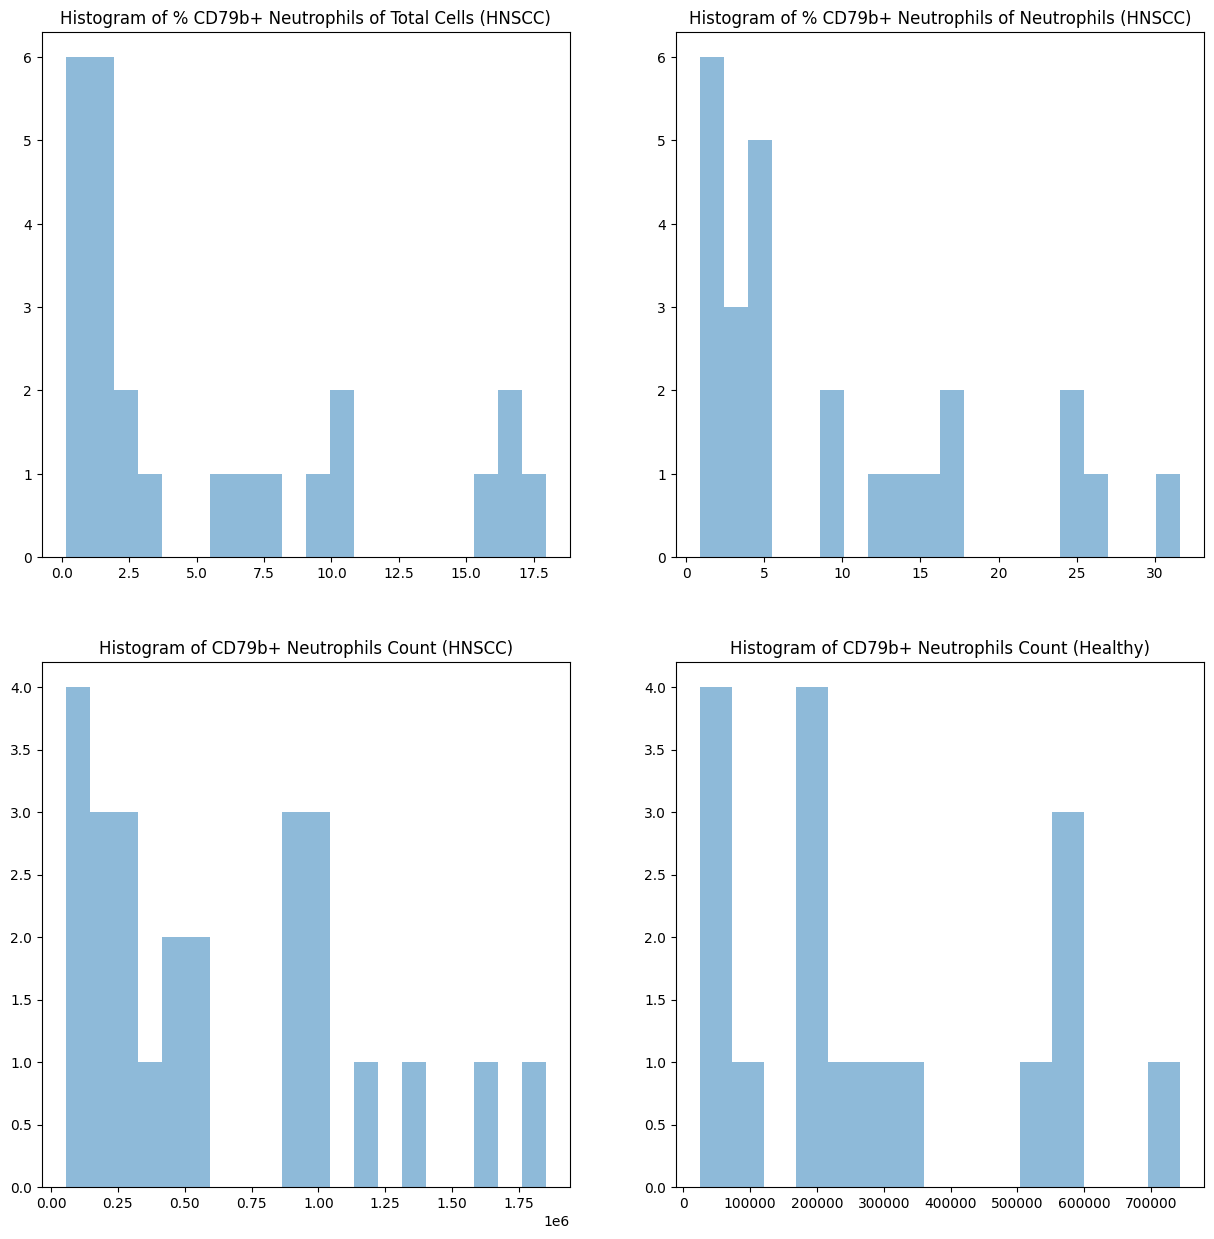

In [31]:
import matplotlib.pyplot as plt

# Create 4 histograms in a 2x2 grid
plt.figure(figsize = (15, 15))
plt.subplot(2, 2, 1)
plt.hist(hnscc_cd79b_total_clean, bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Total Cells (HNSCC)')
plt.subplot(2, 2, 2)
plt.hist(hnscc_cd79b_neut_clean, bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Neutrophils (HNSCC)')
plt.subplot(2, 2, 3)
plt.hist(hnscc_cd79b_neut_count_clean, bins = 20, alpha = 0.5)
plt.title("Histogram of CD79b+ Neutrophils Count (HNSCC)")
plt.subplot(2, 2, 4)
plt.hist(healthy_cd79b_neut_count_clean, bins = 15, alpha = 0.5)
plt.title("Histogram of CD79b+ Neutrophils Count (Healthy)")
plt.show()

In [32]:
# Log transforming non-normal data

hnscc_cd79b_total_log = hnscc_cd79b_total_clean.apply(lambda x: math.log(x + 1))
hnscc_cd79b_neut_log = hnscc_cd79b_neut_clean.apply(lambda x: math.log(x + 1))
hnscc_cd79b_neut_count_log = hnscc_cd79b_neut_count_clean.apply(lambda x: math.log(x + 1))
healthy_cd79b_neut_count_log = healthy_cd79b_neut_count_clean.apply(lambda x: math.log(x + 1))

In [33]:
shapiro_wilk_test(hnscc_cd79b_total_log.to_frame(), '% CD79b+ Neutrophils')

Shapiro-Wilk Test Statistic: 0.9045343067917175, p-value: 0.02305912261158301
Reject the null hypothesis: Data is not normally distributed.


In [34]:
shapiro_wilk_test(hnscc_cd79b_neut_log.to_frame(), '% CD79b+ Neutrophils.1')

Shapiro-Wilk Test Statistic: 0.9312328675316716, p-value: 0.09279902873840319
Fail to reject the null hypothesis: Data is normally distributed.


In [35]:
shapiro_wilk_test(hnscc_cd79b_neut_count_log.to_frame(), 'CD79b+ neutrophils')

Shapiro-Wilk Test Statistic: 0.9507786686888582, p-value: 0.2610467575387528
Fail to reject the null hypothesis: Data is normally distributed.


In [36]:
shapiro_wilk_test(healthy_cd79b_neut_count_log.to_frame(), 'CD79b+ neutrophils')

Shapiro-Wilk Test Statistic: 0.9308527702740962, p-value: 0.22490398297027583
Fail to reject the null hypothesis: Data is normally distributed.


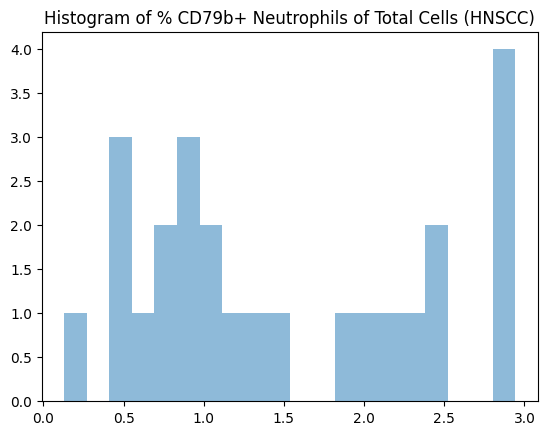

In [37]:
plt.hist(hnscc_cd79b_total_log, bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Total Cells (HNSCC)')
plt.show()

In [38]:
# Arccos transformation 
hnscc_cd79b_total_arccos = hnscc_cd79b_total_clean.apply(lambda x: math.acos(x / 100))
shapiro_wilk_test(hnscc_cd79b_total_arccos.to_frame(), '% CD79b+ Neutrophils')

Shapiro-Wilk Test Statistic: 0.7972225589592754, p-value: 0.00020441019862193309
Reject the null hypothesis: Data is not normally distributed.


In [39]:
# Box-Cox transformation
from scipy import stats
hnscc_cd79b_total_boxcox, _ = stats.boxcox(hnscc_cd79b_total_clean + 1) # add 1 to avoid zero values
shapiro_wilk_test(pd.DataFrame(hnscc_cd79b_total_boxcox, columns=['% CD79b+ Neutrophils']), '% CD79b+ Neutrophils')

Shapiro-Wilk Test Statistic: 0.9221180749763591, p-value: 0.057264801684732566
Fail to reject the null hypothesis: Data is normally distributed.


In [40]:
# Yeo-Johnson transformation
hnscc_cd79b_total_yeojohnson, _ = stats.yeojohnson(hnscc_cd79b_total_clean)
shapiro_wilk_test(pd.DataFrame(hnscc_cd79b_total_yeojohnson, columns=['% CD79b+ Neutrophils']), '% CD79b+ Neutrophils')

Shapiro-Wilk Test Statistic: 0.922118074258974, p-value: 0.05726479952233309
Fail to reject the null hypothesis: Data is normally distributed.


In [41]:
hnscc_neut_clean.to_excel('hnscc_neut_clean.xlsx', index = False)

In [42]:
hnscc_cd79b_neut_log.to_excel('hnscc_cd79b_neut_log.xlsx', index = False)
hnscc_cd79b_neut_count_log.to_excel('hnscc_cd79b_neut_count_log.xlsx', index = False)
healthy_neut_clean.to_excel('healthy_neut_clean.xlsx', index = False)
healthy_cd79b_total_clean.to_excel('healthy_cd79b_total_clean.xlsx', index = False)
healthy_cd79b_neut_clean.to_excel('healthy_cd79b_neut_clean.xlsx', index = False)
healthy_cd79b_neut_count_log.to_excel('healthy_cd79b_neut_count_log.xlsx', index = False)

In [43]:
# to excel hnscc_cd79b_total_boxcox
hnscc_cd79b_total_boxcox_df = pd.DataFrame(hnscc_cd79b_total_boxcox, columns=['% CD79b+ Neutrophils'])

In [44]:
# dataframe for hnscc columns
hnscc_df = pd.DataFrame({
    '% Neutrophils': hnscc_neut_clean,
    '% CD79b+ Neutrophils of Total': hnscc_cd79b_total_boxcox,
    '% CD79b+ Neutrophils of Neutrophils': hnscc_cd79b_neut_log,
    'CD79b+ Neutrophils Count': hnscc_cd79b_neut_count_log
})

healthy_df = pd.DataFrame({
    '% Neutrophils': healthy_neut_clean,
    '% CD79b+ Neutrophils of Total': healthy_cd79b_total_clean,
    '% CD79b+ Neutrophils of Neutrophils': healthy_cd79b_neut_clean,
    'CD79b+ Neutrophils Count': healthy_cd79b_neut_count_log
})

In [53]:
hnscc_df.to_excel('hnscc_clean_data.xlsx', index = False)
healthy_df.to_excel('healthy_clean_data.xlsx', index = False)

Needs to be using kruskal-wallis test to compare these groups followed by dunn post hoc test,

For new data, wants to see the difference between responder vs nonresponder. Also anti-PD1 treatment (-mab). Also wants to see if possible to take gender out of the equation, see if this is an unbiased variable.
  









In [45]:
import scipy.stats as stats

# t test 
stats.ttest_ind(hnscc_clean['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var = False)

TtestResult(statistic=np.float64(1.6426557328047358), pvalue=np.float64(0.10834732584920978), df=np.float64(39.72742874512458))

In [46]:
hnscc_stage = hnscc_clean[hnscc_clean['Calculated Stage '] > 0.0]
hnscc_stage

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
5,59.082132,15.575825,26.363004,9.843921e+05,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
9,70.184651,2.200405,3.135166,5.619835e+05,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
11,65.447223,10.547072,16.115385,4.993511e+05,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
12,56.003139,9.424162,16.827918,4.735641e+05,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
13,50.834092,1.347545,2.650869,3.258365e+05,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0


In [47]:
hnscc_stage1 = hnscc_stage[hnscc_stage['Calculated Stage '] == 1.0]
hnscc_stage2 = hnscc_stage[hnscc_stage['Calculated Stage '] == 2.0]
hnscc_stage3 = hnscc_stage[hnscc_stage['Calculated Stage '] == 3.0]
hnscc_stage4 = hnscc_stage[hnscc_stage['Calculated Stage '] == 4.0]

In [48]:
hnscc_stage1

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
20,76.987091,0.138696,1.801663,5.475728e+04,42.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-mediated squamous c...,HPV mediated squamous cell carcinoma,"Tonsil, oropharynx, lymph node",positive,Positive,PT1 pN1 ENE (+),Positive,1.0
21,46.500000,1.840000,3.970000,9.328800e+05,51.0,Male,White,Not Hispanic or Latino,"Oropharyngeal squamous cell carcinoma, HPV ass...",Oropharyngeal Squamous cell carcinoma,Tonsil,NaN,postive,pT1,negative,1.0


In [49]:
hnscc_stage2

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
9,70.184651,2.200405,3.135166,561983.504095,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
18,60.606628,2.752294,4.541242,151513.761468,78.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Gum,NaN,NaN,pT2pN0,negative,2.0


In [50]:
hnscc_stage3

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
12,56.003139,9.424162,16.827918,4.735641e+05,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0
16,46.261079,7.546683,16.313244,2.020247e+05,61.0,Female,White,Not Hispanic or Latino,HPV mediated squamous cell carcinoma of the or...,HPV mediated squamous cell carcinoma,"oropharynx, tonsil",NaN,Positive,pT2pN1,positive,3.0
23,7.490000,0.690000,9.180000,1.250625e+05,58.0,Male,White,Not Hispanic or Latino,Human papillomavirus / HPV-mediated squamous ...,HPV mediated squamous cell carcinoma,oropharynx,positive,positive,pT2pN1,Positive,3.0


In [51]:
hnscc_stage4

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
5,59.082132,15.575825,26.363004,9.843921e+05,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
11,65.447223,10.547072,16.115385,4.993511e+05,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
13,50.834092,1.347545,2.650869,3.258365e+05,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
17,60.905829,5.976590,9.810000,1.596347e+05,32.0,Female,White,Hispanic or Latino,"Squamous cell carcinoma, moderate to poorly di...",Squamous cell carcinoma,tongue,NaN,NaN,pT4apN0,negative,4.0
19,60.511612,3.085167,5.098471,1.252578e+05,74.0,Male,White,Not Hispanic or Latino,"Invasive, moderately differentiated keratinizi...",Squamous cell carcinoma of the oral cavity,Oral cavity,NaN,NaN,pT4apN0,negative,4.0
24,20.900000,0.910000,4.370000,9.227400e+04,51.0,Male,White,Not Hispanic or Latino,Invasive moderately to poorly differentiated s...,Squamous cell carcinoma,tongue,positive,NaN,pT4apN3b,Positive,4.0


In [52]:
You can analyze the stages of HNSCC (Head and Neck Squamous Cell Carcinoma) to gain insights into the data. Here are some ideas:

1. **Distribution Analysis**:
    - Plot the distribution of patients across different stages using a bar chart or pie chart.

2. **Statistical Comparison**:
    - Compare the values of key metrics (e.g., `% CD79b+ Neutrophils`, `Age`) across different stages using statistical tests like ANOVA or t-tests.

3. **Correlation Analysis**:
    - Analyze the correlation between `Calculated Stage` and other numerical features.

4. **Visualization**:
    - Create boxplots or violin plots to visualize the distribution of numerical features across stages.

5. **Survival Analysis**:
    - If survival data is available, perform survival analysis to study the impact of stages on patient outcomes.

6. **Feature Importance**:
    - Use machine learning models to identify features that are most predictive of the stage.

7. **Group-wise Analysis**:
    - Analyze demographic or clinical differences (e.g., `Sex`, `Race`, `HPV status`) across stages.

Let me know which analysis you'd like to perform, and I can help you write the code!
```python
from scipy.stats import f_oneway

# Perform ANOVA to compare % CD79b+ Neutrophils across stages
anova_result = f_oneway(hnscc_stage1['% CD79b+ Neutrophils'], 
                        hnscc_stage2['% CD79b+ Neutrophils'], 
                        hnscc_stage3['% CD79b+ Neutrophils'], 
                        hnscc_stage4['% CD79b+ Neutrophils'])

anova_result
```python
# Perform t-tests to compare % CD79b+ Neutrophils between each stage and healthy patients
t_test_stage1 = stats.ttest_ind(hnscc_stage1['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage2 = stats.ttest_ind(hnscc_stage2['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage3 = stats.ttest_ind(hnscc_stage3['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage4 = stats.ttest_ind(hnscc_stage4['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)

t_test_stage1, t_test_stage2, t_test_stage3, t_test_stage4
```python
# Evaluate statistical significance of t-tests
P
```

SyntaxError: unterminated string literal (detected at line 24) (1525446706.py, line 24)

In [ ]:
from scipy.stats import f_oneway

anova_result = f_oneway(hnscc_stage1['% CD79b+ Neutrophils'], 
                        hnscc_stage2['% CD79b+ Neutrophils'], 
                        hnscc_stage3['% CD79b+ Neutrophils'],
                        hnscc_stage4['% CD79b+ Neutrophils'])

anova_result

F_onewayResult(statistic=np.float64(0.826824656585741), pvalue=np.float64(0.5007894985430368))

In [ ]:
t_test_stage1 = stats.ttest_ind(hnscc_stage1['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage2 = stats.ttest_ind(hnscc_stage2['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage3 = stats.ttest_ind(hnscc_stage3['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage4 = stats.ttest_ind(hnscc_stage4['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)

t_test_stage1, t_test_stage2, t_test_stage3, t_test_stage4

(TtestResult(statistic=np.float64(1.3136992552620153), pvalue=np.float64(0.31365320813287567), df=np.float64(2.108589018895414)),
 TtestResult(statistic=np.float64(0.422190831293264), pvalue=np.float64(0.7382709374143084), df=np.float64(1.1485084759775832)),
 TtestResult(statistic=np.float64(0.9822490899610051), pvalue=np.float64(0.3776771575405677), df=np.float64(4.325226341846808)),
 TtestResult(statistic=np.float64(1.575539650649454), pvalue=np.float64(0.15403513524110107), df=np.float64(7.946306897633376)))

In [ ]:
from scipy.stats import mannwhitneyu

mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
hnscc_ln_pos = hnscc_clean[hnscc_clean['lymph node stage'].isin(['Positive', 'positive', 'postitive'])]
hnscc_ln_pos

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
5,59.082132,15.575825,26.363004,984392.127861,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
11,65.447223,10.547072,16.115385,499351.107568,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
12,56.003139,9.424162,16.827918,473564.141848,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
13,50.834092,1.347545,2.650869,325836.474717,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
16,46.261079,7.546683,16.313244,202024.696670,61.0,Female,White,Not Hispanic or Latino,HPV mediated squamous cell carcinoma of the or...,HPV mediated squamous cell carcinoma,"oropharynx, tonsil",NaN,Positive,pT2pN1,positive,3.0
20,76.987091,0.138696,1.801663,54757.281553,42.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-mediated squamous c...,HPV mediated squamous cell carcinoma,"Tonsil, oropharynx, lymph node",positive,Positive,PT1 pN1 ENE (+),Positive,1.0
23,7.490000,0.690000,9.180000,125062.500000,58.0,Male,White,Not Hispanic or Latino,Human papillomavirus / HPV-mediated squamous ...,HPV mediated squamous cell carcinoma,oropharynx,positive,positive,pT2pN1,Positive,3.0
24,20.900000,0.910000,4.370000,92274.000000,51.0,Male,White,Not Hispanic or Latino,Invasive moderately to poorly differentiated s...,Squamous cell carcinoma,tongue,positive,NaN,pT4apN3b,Positive,4.0


In [ ]:
hnscc_ln_neg = hnscc_clean[hnscc_clean['lymph node stage'].isin(['Negative', 'negative', 'negative*'])]
hnscc_ln_neg

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
9,70.184651,2.200405,3.135166,5.619835e+05,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0
17,60.905829,5.976590,9.810000,1.596347e+05,32.0,Female,White,Hispanic or Latino,"Squamous cell carcinoma, moderate to poorly di...",Squamous cell carcinoma,tongue,NaN,NaN,pT4apN0,negative,4.0
18,60.606628,2.752294,4.541242,1.515138e+05,78.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Gum,NaN,NaN,pT2pN0,negative,2.0
19,60.511612,3.085167,5.098471,1.252578e+05,74.0,Male,White,Not Hispanic or Latino,"Invasive, moderately differentiated keratinizi...",Squamous cell carcinoma of the oral cavity,Oral cavity,NaN,NaN,pT4apN0,negative,4.0
21,46.500000,1.840000,3.970000,9.328800e+05,51.0,Male,White,Not Hispanic or Latino,"Oropharyngeal squamous cell carcinoma, HPV ass...",Oropharyngeal Squamous cell carcinoma,Tonsil,NaN,postive,pT1,negative,1.0


In [ ]:
# Compare LN Neg and Pos to healthy

mannwhitneyu_neg = mannwhitneyu(hnscc_ln_neg['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_pos = mannwhitneyu(hnscc_ln_pos['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])

results = {
    "LN Negative": mannwhitneyu_neg.pvalue,
    "LN Positive": mannwhitneyu_pos.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'LN Negative': 'Significant', 'LN Positive': 'Not Significant'}

<ErrorbarContainer object of 3 artists>

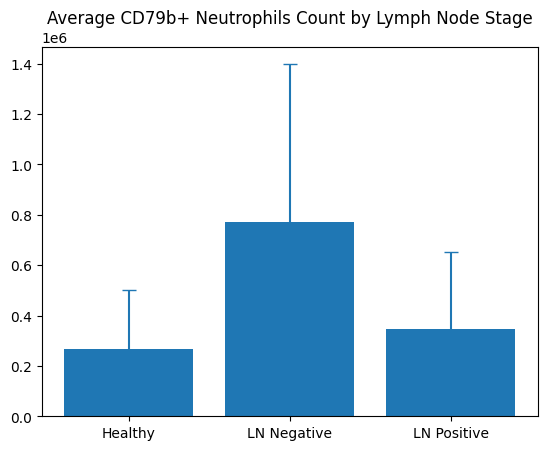

In [ ]:
plt.bar(['Healthy','LN Negative', 'LN Positive'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_ln_neg['CD79b+ neutrophils'].mean(), hnscc_ln_pos['CD79b+ neutrophils'].mean()])
plt.title('Average CD79b+ Neutrophils Count by Lymph Node Stage')
plt.errorbar(['Healthy','LN Negative', 'LN Positive'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_ln_neg['CD79b+ neutrophils'].mean(), hnscc_ln_pos['CD79b+ neutrophils'].mean()], 
             yerr=[healthy_clean['CD79b+ neutrophils'].std(), hnscc_ln_neg['CD79b+ neutrophils'].std(), hnscc_ln_pos['CD79b+ neutrophils'].std()], fmt='none', capsize=5)

<BarContainer object of 2 artists>

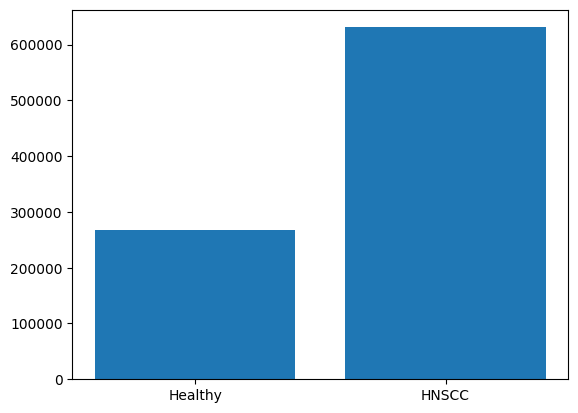

In [ ]:
plt.bar(['Healthy', 'HNSCC'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_clean['CD79b+ neutrophils'].mean()])

In [ ]:
hnscc_clean.columns

Index(['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1',
       'CD79b+ neutrophils', 'Age', 'Sex', 'Race', 'Ethnicity',
       'Diagnosis (as listed in KUMC excel)', 'Final Diagnosis ', 'Location',
       'Metastisis', 'HPV status', 'staging', 'lymph node stage',
       'Calculated Stage '],
      dtype='object')

<Axes: xlabel='Calculated Stage ', ylabel='CD79b+ neutrophils'>

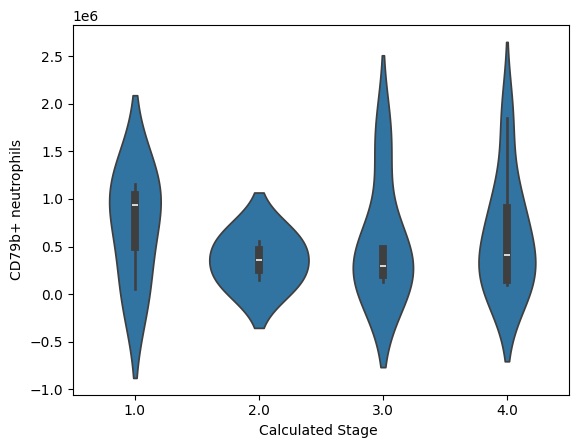

In [ ]:
sns.violinplot(x = 'Calculated Stage ', y = 'CD79b+ neutrophils', data = hnscc_clean)

In [45]:
hnscc_female = hnscc_clean[hnscc_clean['Sex'] == 'Female']
hnscc_female = hnscc_female['% Neutrophils']
hnscc_female

1     71.077168
3     70.418280
6     45.770065
8     51.127396
10    72.000821
12    56.003139
14    61.225209
15    74.972412
16    46.261079
17    60.905829
22    66.200000
Name: % Neutrophils, dtype: float64

In [46]:
hnscc_male = hnscc_clean[hnscc_clean['Sex'] == 'Male']
hnscc_male = hnscc_male['% Neutrophils']
hnscc_male

0     64.692559
2     58.012654
4     35.800000
5     59.082132
7     52.541020
9     70.184651
11    65.447223
13    50.834092
18    60.606628
19    60.511612
20    76.987091
21    46.500000
23     7.490000
24    20.900000
Name: % Neutrophils, dtype: float64

In [47]:
import scipy.stats as stats

# Calculate sample variances (ddof=1 for unbiased sample variance)
var_f = np.var(hnscc_female, ddof=1)
var_m = np.var(hnscc_male, ddof=1)

# Compute F-statistic (Conventionally: larger variance / smaller variance)
f_stat = var_f / var_m if var_f > var_m else var_m / var_f

# Degrees of freedom
df1 = len(hnscc_female) - 1 if var_f > var_m else len(hnscc_male) - 1
df2 = len(hnscc_male) - 1 if var_f > var_m else len(hnscc_female) - 1

# Calculate two-tailed p-value
p_value = 2 * (1 - stats.f.cdf(f_stat, df1, df2))

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")


F-Statistic: 3.3282
P-Value: 0.0638


(array([1., 0., 1., 0., 0., 0., 1., 0., 1., 2., 1., 3., 2., 1., 1.]),
 array([ 7.49      , 12.12313937, 16.75627874, 21.38941812, 26.02255749,
        30.65569686, 35.28883623, 39.9219756 , 44.55511498, 49.18825435,
        53.82139372, 58.45453309, 63.08767246, 67.72081184, 72.35395121,
        76.98709058]),
 <BarContainer object of 15 artists>)

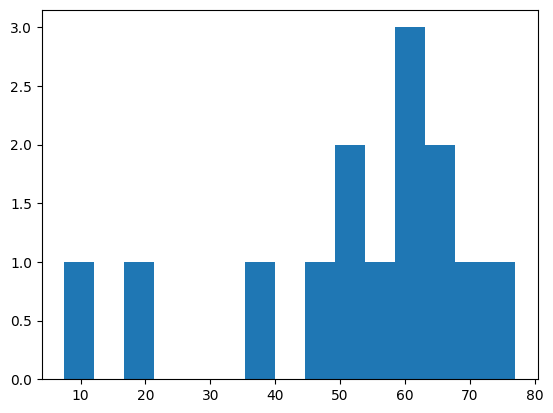

In [50]:
plt.hist(hnscc_male, bins=15)